# AA3 · Proyecto integrador · Avance 1
## Clasificador multi-tarea de producto y nivel de madurez con MobileNetV2

**Aprendizaje Automático III (IN1042) · Grupo A7 · Otoño 2026**
Autor: Rodrigo Rosales Díaz

A partir de una sola fotografía, el modelo responde dos preguntas:
1. **¿Qué producto es?** → manzana / plátano / naranja
2. **¿Qué nivel de madurez tiene?** → verde / maduro / podrido

Arquitectura: MobileNetV2 preentrenada en ImageNet con un cuerpo compartido y **dos cabezas de salida**. Entrenamiento por transferencia de conocimiento en dos fases: (1) cabezas con el backbone congelado y (2) fine-tuning de los últimos bloques.

In [1]:
# Instalar dependencias si faltan (descomentar la primera vez)
# %pip install torch torchvision scikit-learn pandas matplotlib pillow

## 1. Configuración e hiperparámetros

In [2]:
import os, random, hashlib, time, json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, f1_score, accuracy_score)

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Dispositivo:", device, "|", torch.cuda.get_device_name(0) if device.type == "cuda" else "")
print("PyTorch", torch.__version__)

ROOT = Path(r"C:\Users\rodri\.cache\kagglehub\datasets\leftin\fruit-ripeness-unripe-ripe-and-rotten\versions\2\fruit_ripeness_dataset\archive (1)\dataset")
FIG_DIR = Path("figuras"); FIG_DIR.mkdir(exist_ok=True)

CFG = dict(
    arquitectura="MobileNetV2 preentrenada (ImageNet1K_V2), 2 cabezas",
    tamano_imagen=224,
    batch_size=64,
    fraccion_validacion=0.15,
    optimizador="AdamW",
    weight_decay=1e-4,
    dropout=0.2,
    fase1_epocas=5,
    fase1_lr=1e-3,
    fase2_epocas=12,
    fase2_lr=1e-4,
    bloques_descongelados_fase2=5,
    scheduler_fase2="CosineAnnealingLR",
    paciencia_early_stopping=3,
    perdida="CE(producto) + λ·CE(madurez)",
    lambda_madurez=1.0,
    precision_mixta=True,
    semilla=SEED,
)
pd.DataFrame({"valor": {k: str(v) for k, v in CFG.items()}})

Dispositivo: cuda | NVIDIA GeForce RTX 4050 Laptop GPU
PyTorch 2.14.0+cu126


,valor
arquitectura,"MobileNetV2 preentrenada (ImageNet1K_V2), 2 ca..."
tamano_imagen,224
batch_size,64
fraccion_validacion,0.15
optimizador,AdamW
weight_decay,0.0001
dropout,0.2
fase1_epocas,5
fase1_lr,0.001
fase2_epocas,12


## 2. Datos: inventario y mapeo de etiquetas
Dataset: *Fruit Ripeness: Unripe, Ripe, and Rotten* (Kaggle, `leftin`). Cada carpeta combina producto y estado. Se mapea a dos etiquetas independientes con una escala común de madurez:

| Prefijo original | Escala común |
|---|---|
| `unripe` | verde |
| `fresh` | maduro |
| `rotten` | podrido |

In [3]:
PRODUCTOS = ["manzana", "platano", "naranja"]
MADUREZ   = ["verde", "maduro", "podrido"]
EXT = (".jpg", ".jpeg", ".png")

def etiquetar(carpeta):
    c = carpeta.lower().replace(" ", "")
    prod = ("manzana" if "apple" in c else "platano" if "banana" in c
            else "naranja" if "orange" in c else None)
    mad = ("verde" if c.startswith("unripe") else "maduro" if c.startswith("fresh")
           else "podrido" if c.startswith("rotten") else None)
    return prod, mad

filas = []
for split in ["train", "test"]:
    for carpeta in sorted(os.listdir(ROOT / split)):
        prod, mad = etiquetar(carpeta)
        if prod is None or mad is None:
            print("Carpeta ignorada:", carpeta); continue
        for f in os.listdir(ROOT / split / carpeta):
            if f.lower().endswith(EXT):
                filas.append(dict(ruta=str(ROOT / split / carpeta / f), origen=split,
                                  carpeta=carpeta, producto=prod, madurez=mad))

df = pd.DataFrame(filas)
df["prod_id"] = df.producto.map({p: i for i, p in enumerate(PRODUCTOS)})
df["mad_id"]  = df.madurez.map({m: i for i, m in enumerate(MADUREZ)})
df["clase"]   = df.producto + "-" + df.madurez
print("Total de imágenes:", len(df))

# Tabla de mapeo carpeta -> (producto, madurez)
df.groupby("carpeta")[["producto", "madurez"]].first()

Total de imágenes: 19956


,producto,madurez
carpeta,,
freshapples,manzana,maduro
freshbanana,platano,maduro
freshoranges,naranja,maduro
rottenapples,manzana,podrido
rottenbanana,platano,podrido
rottenoranges,naranja,podrido
unripe apple,manzana,verde
unripe banana,platano,verde
unripe orange,naranja,verde


## 3. Control de calidad: duplicados y fuga de datos
La descarga contiene una carpeta anidada `dataset/dataset` con los mismos conteos; se verifica que sea una copia y solo se usa una. Además, se buscan imágenes **idénticas** (hash MD5) repetidas dentro del conjunto y entre entrenamiento y prueba: si una misma foto aparece en ambos, la métrica de prueba se infla.

In [4]:
anidada = ROOT / "dataset"
if anidada.exists():
    a = {(p.parent.name, p.name) for p in (ROOT / "train").rglob("*") if p.suffix.lower() in EXT}
    b = {(p.parent.name, p.name) for p in (anidada / "train").rglob("*") if p.suffix.lower() in EXT}
    print("¿La carpeta anidada es copia (mismos nombres)?", a == b)

def md5(ruta):
    with open(ruta, "rb") as f:
        return hashlib.md5(f.read()).hexdigest()

t0 = time.time()
df["md5"] = [md5(p) for p in df.ruta]
print(f"Hashes calculados en {time.time()-t0:.0f} s")

hash_train = set(df.loc[df.origen == "train", "md5"])
fuga = (df.origen == "test") & df.md5.isin(hash_train)
print("Duplicados exactos dentro de todo el conjunto:", df.duplicated("md5").sum())
print("Imágenes de prueba idénticas a alguna de entrenamiento:", fuga.sum())

n0 = len(df)
df = df[~fuga]                                   # quitar de prueba lo que ya está en train
df = df.drop_duplicates("md5", keep="first")     # una sola copia de cada imagen
print(f"Imágenes eliminadas: {n0 - len(df)}  ->  quedan {len(df)}")

¿La carpeta anidada es copia (mismos nombres)? True
Hashes calculados en 140 s
Duplicados exactos dentro de todo el conjunto: 153
Imágenes de prueba idénticas a alguna de entrenamiento: 0
Imágenes eliminadas: 153  ->  quedan 19803


## 4. División entrenamiento / validación / prueba

In [5]:
d_tr_full = df[df.origen == "train"]
d_train, d_val = train_test_split(d_tr_full, test_size=CFG["fraccion_validacion"],
                                  stratify=d_tr_full.clase, random_state=SEED)
d_test = df[df.origen == "test"]

conteo = pd.concat({"entrenamiento": d_train.clase.value_counts(),
                    "validación": d_val.clase.value_counts(),
                    "prueba": d_test.clase.value_counts()}, axis=1).sort_index()
conteo.loc["TOTAL"] = conteo.sum()
conteo

,entrenamiento,validación,prueba
clase,,,
manzana-maduro,1439,254,395
manzana-podrido,1991,351,601
manzana-verde,1644,290,306
naranja-maduro,1246,220,388
naranja-podrido,1356,239,403
naranja-verde,1091,193,240
platano-maduro,1344,237,381
platano-podrido,1890,334,530
platano-verde,1782,315,343


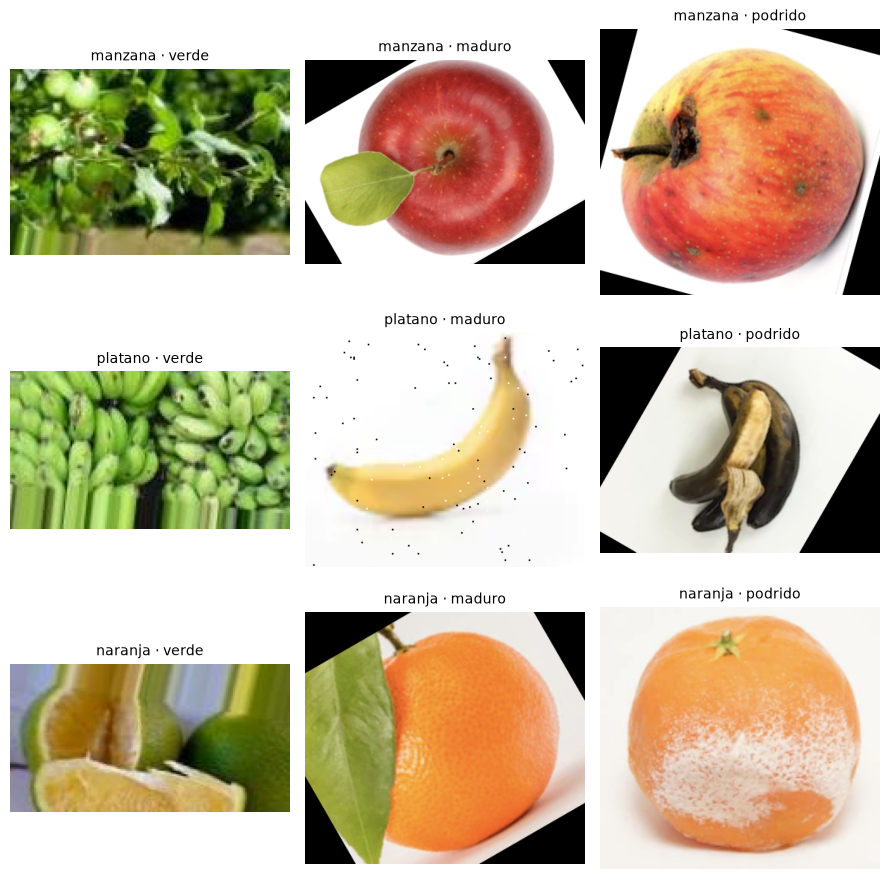

In [6]:
# Figura: ejemplos por clase (producto x madurez)
fig, axes = plt.subplots(3, 3, figsize=(9, 9))
for i, p in enumerate(PRODUCTOS):
    for j, m in enumerate(MADUREZ):
        ruta = d_train[(d_train.producto == p) & (d_train.madurez == m)].sample(1, random_state=SEED).ruta.iloc[0]
        axes[i, j].imshow(Image.open(ruta).convert("RGB")); axes[i, j].axis("off")
        axes[i, j].set_title(f"{p} · {m}", fontsize=10)
plt.tight_layout(); plt.savefig(FIG_DIR / "ejemplos_por_clase.png", dpi=150); plt.show()

## 5. Preprocesamiento y aumento de datos
- Redimensionado a 224×224 y normalización con medias/desviaciones de ImageNet (lo que espera MobileNetV2).
- Aumento en entrenamiento: recorte aleatorio, volteos, rotación y cambios **moderados** de brillo y contraste.
- **No** se altera el tono (*hue*): el color es la señal principal de madurez y cambiarlo podría convertir un plátano verde en uno maduro.

In [7]:
MEAN, STD = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]
tf_train = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])
tf_eval = transforms.Compose([
    transforms.Resize(256), transforms.CenterCrop(224),
    transforms.ToTensor(), transforms.Normalize(MEAN, STD),
])

class FrutaDS(Dataset):
    def __init__(self, d, tf):
        self.rutas = d.ruta.tolist()
        self.yp = d.prod_id.tolist()
        self.ym = d.mad_id.tolist()
        self.tf = tf
    def __len__(self):
        return len(self.rutas)
    def __getitem__(self, i):
        img = Image.open(self.rutas[i]).convert("RGB")
        return self.tf(img), self.yp[i], self.ym[i]

# num_workers=0: en Jupyter + Windows los workers no pueden serializar clases del notebook
kw = dict(batch_size=CFG["batch_size"], num_workers=0, pin_memory=True)
dl_train = DataLoader(FrutaDS(d_train, tf_train), shuffle=True, **kw)
dl_val   = DataLoader(FrutaDS(d_val, tf_eval), shuffle=False, **kw)
dl_test  = DataLoader(FrutaDS(d_test, tf_eval), shuffle=False, **kw)
print(len(dl_train), "lotes de entrenamiento |", len(dl_val), "de validación |", len(dl_test), "de prueba")

216 lotes de entrenamiento | 39 de validación | 57 de prueba


## 6. Arquitectura: MobileNetV2 con dos cabezas
Un solo cuerpo convolucional (backbone) extrae un vector de 1280 características por imagen; dos capas lineales independientes lo convierten en la predicción de **producto** y de **madurez**. La pérdida total es la suma de las dos entropías cruzadas.

El método `embedding()` devuelve ese vector de 1280 valores: es lo que se usará en el segundo parcial como entrada de la red recurrente.

In [8]:
class MultiCabeza(nn.Module):
    def __init__(self, n_prod, n_mad, dropout=0.2):
        super().__init__()
        base = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V2)
        self.backbone = base.features
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.drop = nn.Dropout(dropout)
        self.cabeza_producto = nn.Linear(1280, n_prod)
        self.cabeza_madurez  = nn.Linear(1280, n_mad)

    def embedding(self, x):
        return torch.flatten(self.pool(self.backbone(x)), 1)

    def forward(self, x):
        z = self.drop(self.embedding(x))
        return self.cabeza_producto(z), self.cabeza_madurez(z)

model = MultiCabeza(len(PRODUCTOS), len(MADUREZ), CFG["dropout"]).to(device)

def contar(m, solo_entrenables=False):
    return sum(p.numel() for p in m.parameters() if p.requires_grad or not solo_entrenables)
print(f"Parámetros totales: {contar(model):,}")

Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to C:\Users\rodri/.cache\torch\hub\checkpoints\mobilenet_v2-7ebf99e0.pth


100%|██████████| 13.6M/13.6M [00:02<00:00, 5.14MB/s]


Parámetros totales: 2,231,558


## 7. Rutinas de entrenamiento

In [9]:
crit = nn.CrossEntropyLoss()
scaler = torch.amp.GradScaler("cuda", enabled=CFG["precision_mixta"])

def modo_entrenamiento(m):
    # Las capas congeladas mantienen sus estadísticas de BatchNorm de ImageNet
    m.train()
    for mod in m.backbone.modules():
        if isinstance(mod, nn.BatchNorm2d) and not any(p.requires_grad for p in mod.parameters()):
            mod.eval()

def correr_epoca(m, loader, opt=None):
    entrenar = opt is not None
    if entrenar:
        modo_entrenamiento(m)
    else:
        m.eval()
    s_loss, ok_p, ok_m, n = 0.0, 0, 0, 0
    with torch.set_grad_enabled(entrenar):
        for x, yp, ym in loader:
            x = x.to(device, non_blocking=True); yp = yp.to(device); ym = ym.to(device)
            with torch.autocast("cuda", dtype=torch.float16, enabled=CFG["precision_mixta"]):
                lp, lm = m(x)
                loss = crit(lp, yp) + CFG["lambda_madurez"] * crit(lm, ym)
            if entrenar:
                opt.zero_grad(set_to_none=True)
                scaler.scale(loss).backward()
                scaler.step(opt); scaler.update()
            b = x.size(0)
            s_loss += loss.item() * b
            ok_p += (lp.argmax(1) == yp).sum().item()
            ok_m += (lm.argmax(1) == ym).sum().item()
            n += b
    return s_loss / n, ok_p / n, ok_m / n

historial = []
mejor = {"val_loss": float("inf"), "epoca": None}

def entrenar_fase(fase, epocas, opt, sched=None, paciencia=None):
    sin_mejora = 0
    for _ in range(epocas):
        t0 = time.time()
        lr = opt.param_groups[0]["lr"]
        tr = correr_epoca(model, dl_train, opt)
        va = correr_epoca(model, dl_val)
        if sched: sched.step()
        h = dict(fase=fase, epoca=len(historial) + 1, lr=lr,
                 train_loss=tr[0], train_acc_prod=tr[1], train_acc_mad=tr[2],
                 val_loss=va[0], val_acc_prod=va[1], val_acc_mad=va[2], seg=time.time() - t0)
        historial.append(h)
        print(f"[{fase}] época {h['epoca']:2d} | pérdida {tr[0]:.4f} / {va[0]:.4f} | "
              f"producto {tr[1]:.3f} / {va[1]:.3f} | madurez {tr[2]:.3f} / {va[2]:.3f} | {h['seg']:.0f} s")
        if va[0] < mejor["val_loss"]:
            mejor.update(val_loss=va[0], epoca=h["epoca"])
            torch.save(model.state_dict(), "mejor_modelo.pth")
            sin_mejora = 0
        else:
            sin_mejora += 1
            if paciencia and sin_mejora >= paciencia:
                print(f"Early stopping: {paciencia} épocas sin mejorar la pérdida de validación")
                break

## 8. Fase 1 — Transferencia de conocimiento: solo las cabezas
El backbone se congela: conserva lo que aprendió en ImageNet (bordes, texturas, colores) y solo se entrenan las dos cabezas nuevas.

In [10]:
for p in model.backbone.parameters():
    p.requires_grad = False
print(f"Parámetros entrenables en fase 1: {contar(model, True):,}")

opt1 = torch.optim.AdamW([p for p in model.parameters() if p.requires_grad],
                         lr=CFG["fase1_lr"], weight_decay=CFG["weight_decay"])
entrenar_fase("F1", CFG["fase1_epocas"], opt1)

Parámetros entrenables en fase 1: 7,686
[F1] época  1 | pérdida 0.6119 / 0.3640 | producto 0.885 / 0.923 | madurez 0.939 / 0.972 | 122 s
[F1] época  2 | pérdida 0.3021 / 0.2701 | producto 0.931 / 0.940 | madurez 0.971 / 0.978 | 91 s
[F1] época  3 | pérdida 0.2520 / 0.2347 | producto 0.939 / 0.943 | madurez 0.977 / 0.980 | 90 s
[F1] época  4 | pérdida 0.2217 / 0.2108 | producto 0.944 / 0.948 | madurez 0.980 / 0.983 | 107 s
[F1] época  5 | pérdida 0.2061 / 0.1976 | producto 0.949 / 0.948 | madurez 0.980 / 0.983 | 110 s


## 9. Fase 2 — Fine-tuning de los últimos bloques
Se descongelan los últimos bloques del backbone (los que detectan patrones más específicos) y se entrenan con un learning rate 10 veces menor, para ajustar sin destruir lo aprendido. Se usa early stopping sobre la pérdida de validación y se guarda el mejor modelo.

In [11]:
for bloque in model.backbone[-CFG["bloques_descongelados_fase2"]:]:
    for p in bloque.parameters():
        p.requires_grad = True
print(f"Parámetros entrenables en fase 2: {contar(model, True):,}")

opt2 = torch.optim.AdamW([p for p in model.parameters() if p.requires_grad],
                         lr=CFG["fase2_lr"], weight_decay=CFG["weight_decay"])
sched2 = torch.optim.lr_scheduler.CosineAnnealingLR(opt2, T_max=CFG["fase2_epocas"])
entrenar_fase("F2", CFG["fase2_epocas"], opt2, sched2, CFG["paciencia_early_stopping"])
print("Mejor época:", mejor)

Parámetros entrenables en fase 2: 1,689,030
[F2] época  6 | pérdida 0.2207 / 0.1135 | producto 0.945 / 0.967 | madurez 0.976 / 0.992 | 91 s
[F2] época  7 | pérdida 0.1006 / 0.0847 | producto 0.971 / 0.977 | madurez 0.993 / 0.995 | 88 s
[F2] época  8 | pérdida 0.0695 / 0.0662 | producto 0.979 / 0.980 | madurez 0.996 / 0.998 | 89 s
[F2] época  9 | pérdida 0.0490 / 0.0532 | producto 0.985 / 0.984 | madurez 0.998 / 0.997 | 88 s
[F2] época 10 | pérdida 0.0402 / 0.0489 | producto 0.989 / 0.984 | madurez 0.998 / 0.998 | 88 s
[F2] época 11 | pérdida 0.0324 / 0.0499 | producto 0.992 / 0.986 | madurez 0.997 / 0.998 | 88 s
[F2] época 12 | pérdida 0.0293 / 0.0428 | producto 0.993 / 0.988 | madurez 0.998 / 0.998 | 87 s
[F2] época 13 | pérdida 0.0250 / 0.0403 | producto 0.993 / 0.988 | madurez 0.999 / 0.998 | 87 s
[F2] época 14 | pérdida 0.0226 / 0.0402 | producto 0.994 / 0.990 | madurez 0.999 / 0.998 | 88 s
[F2] época 15 | pérdida 0.0209 / 0.0435 | producto 0.994 / 0.987 | madurez 0.999 / 0.998 | 8

## 10. Curvas de aprendizaje

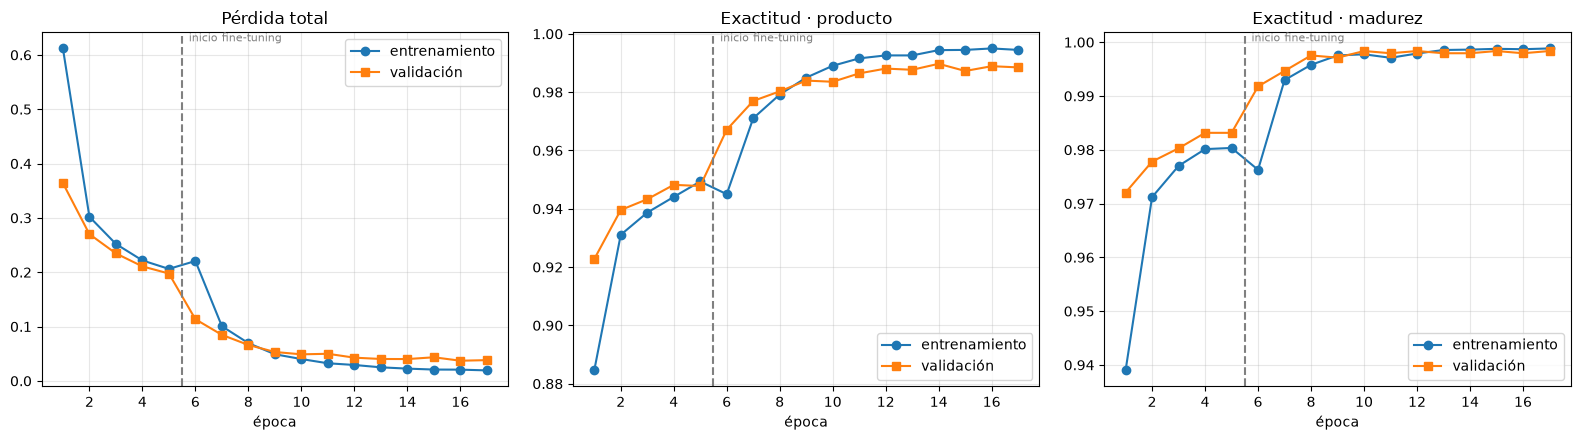

,fase,epoca,lr,train_loss,train_acc_prod,train_acc_mad,val_loss,val_acc_prod,val_acc_mad,seg
0,F1,1,0.0010,0.6119,0.8846,0.9390,0.3640,0.9227,0.9721,121.5016
1,F1,2,0.0010,0.3021,0.9311,0.9712,0.2701,0.9396,0.9778,91.2483
2,F1,3,0.0010,0.2520,0.9387,0.9770,0.2347,0.9433,0.9803,90.0381
3,F1,4,0.0010,0.2217,0.9441,0.9801,0.2108,0.9482,0.9831,106.9657
4,F1,5,0.0010,0.2061,0.9494,0.9803,0.1976,0.9478,0.9831,110.1059
5,F2,6,0.0001,0.2207,0.9450,0.9763,0.1135,0.9671,0.9918,91.3005
6,F2,7,0.0001,0.1006,0.9711,0.9930,0.0847,0.9770,0.9947,87.9441
7,F2,8,0.0001,0.0695,0.9792,0.9958,0.0662,0.9803,0.9975,88.6664
8,F2,9,0.0001,0.0490,0.9850,0.9975,0.0532,0.9840,0.9971,87.8860
9,F2,10,0.0001,0.0402,0.9890,0.9978,0.0489,0.9836,0.9984,87.6895


In [12]:
H = pd.DataFrame(historial)
H.to_csv("historial_entrenamiento.csv", index=False)
fin_f1 = H[H.fase == "F1"].epoca.max()

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, (col, titulo) in zip(axes, [("loss", "Pérdida total"),
                                     ("acc_prod", "Exactitud · producto"),
                                     ("acc_mad", "Exactitud · madurez")]):
    ax.plot(H.epoca, H[f"train_{col}"], "o-", label="entrenamiento")
    ax.plot(H.epoca, H[f"val_{col}"], "s-", label="validación")
    ax.axvline(fin_f1 + 0.5, ls="--", c="gray")
    ax.text(fin_f1 + 0.6, ax.get_ylim()[1], " inicio fine-tuning", va="top", fontsize=8, color="gray")
    ax.set_title(titulo); ax.set_xlabel("época"); ax.grid(alpha=0.3); ax.legend()
plt.tight_layout(); plt.savefig(FIG_DIR / "curvas_aprendizaje.png", dpi=150); plt.show()
H.round(4)

## 11. Evaluación en el conjunto de prueba (mejor modelo)

In [13]:
model.load_state_dict(torch.load("mejor_modelo.pth", map_location=device))
model.eval()

probs_p, probs_m = [], []
with torch.no_grad(), torch.autocast("cuda", dtype=torch.float16, enabled=CFG["precision_mixta"]):
    for x, _, _ in dl_test:
        lp, lm = model(x.to(device))
        probs_p.append(lp.float().softmax(1).cpu()); probs_m.append(lm.float().softmax(1).cpu())
probs_p = torch.cat(probs_p).numpy(); probs_m = torch.cat(probs_m).numpy()

res = d_test.reset_index(drop=True).copy()
res["pred_prod"] = probs_p.argmax(1); res["conf_prod"] = probs_p.max(1)
res["pred_mad"]  = probs_m.argmax(1); res["conf_mad"]  = probs_m.max(1)
res["ok_prod"] = res.pred_prod == res.prod_id
res["ok_mad"]  = res.pred_mad == res.mad_id
res["ok_ambas"] = res.ok_prod & res.ok_mad

resumen = pd.DataFrame({
    "exactitud": [accuracy_score(res.prod_id, res.pred_prod), accuracy_score(res.mad_id, res.pred_mad), res.ok_ambas.mean()],
    "F1 macro":  [f1_score(res.prod_id, res.pred_prod, average="macro"), f1_score(res.mad_id, res.pred_mad, average="macro"), np.nan],
}, index=["producto", "madurez", "ambas correctas"])
print(f"Imágenes de prueba: {len(res)}")
resumen.round(4)

Imágenes de prueba: 3587


,exactitud,F1 macro
producto,0.9944,0.9944
madurez,0.9975,0.9974
ambas correctas,0.9919,NaN


In [14]:
print("=== PRODUCTO ===")
print(classification_report(res.prod_id, res.pred_prod, target_names=PRODUCTOS, digits=4))
print("=== MADUREZ ===")
print(classification_report(res.mad_id, res.pred_mad, target_names=MADUREZ, digits=4))

=== PRODUCTO ===
              precision    recall  f1-score   support

     manzana     0.9923    0.9923    0.9923      1302
     platano     0.9984    0.9976    0.9980      1254
     naranja     0.9922    0.9932    0.9927      1031

    accuracy                         0.9944      3587
   macro avg     0.9943    0.9944    0.9944      3587
weighted avg     0.9944    0.9944    0.9944      3587

=== MADUREZ ===
              precision    recall  f1-score   support

       verde     0.9978    0.9978    0.9978       889
      maduro     0.9940    0.9983    0.9961      1164
     podrido     1.0000    0.9967    0.9984      1534

    accuracy                         0.9975      3587
   macro avg     0.9973    0.9976    0.9974      3587
weighted avg     0.9975    0.9975    0.9975      3587



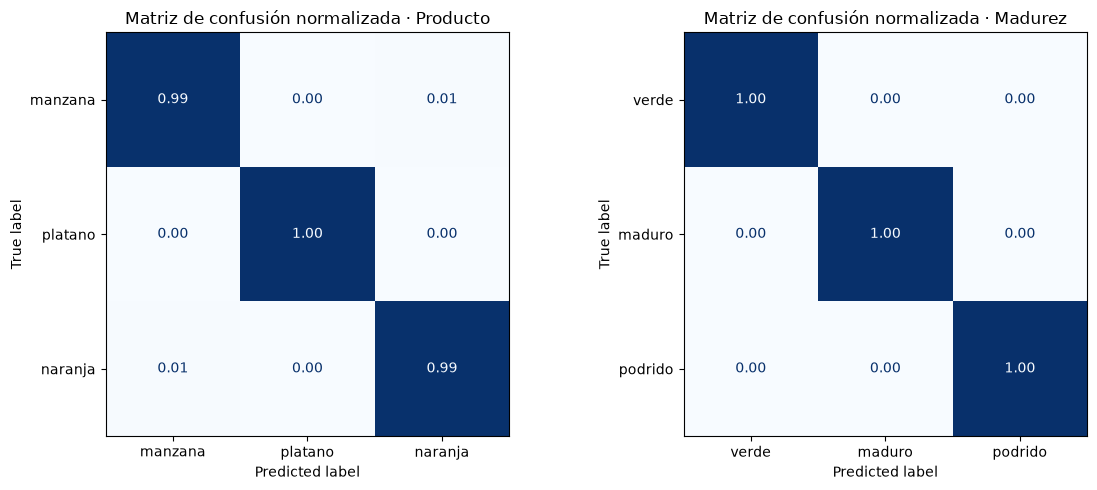

,ok_prod,ok_mad,ok_ambas
producto,,,
manzana,0.9923,0.9939,0.9862
naranja,0.9932,0.9990,0.9922
platano,0.9976,1.0000,0.9976


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (y, yh, nombres, t) in zip(axes, [(res.prod_id, res.pred_prod, PRODUCTOS, "Producto"),
                                          (res.mad_id, res.pred_mad, MADUREZ, "Madurez")]):
    cm = confusion_matrix(y, yh, normalize="true")
    ConfusionMatrixDisplay(cm, display_labels=nombres).plot(ax=ax, cmap="Blues", values_format=".2f", colorbar=False)
    ax.set_title(f"Matriz de confusión normalizada · {t}")
plt.tight_layout(); plt.savefig(FIG_DIR / "matrices_confusion.png", dpi=150); plt.show()

# Exactitud de madurez desglosada por producto
res.groupby("producto")[["ok_prod", "ok_mad", "ok_ambas"]].mean().round(4)

## 12. Capturas de predicciones: aciertos y errores

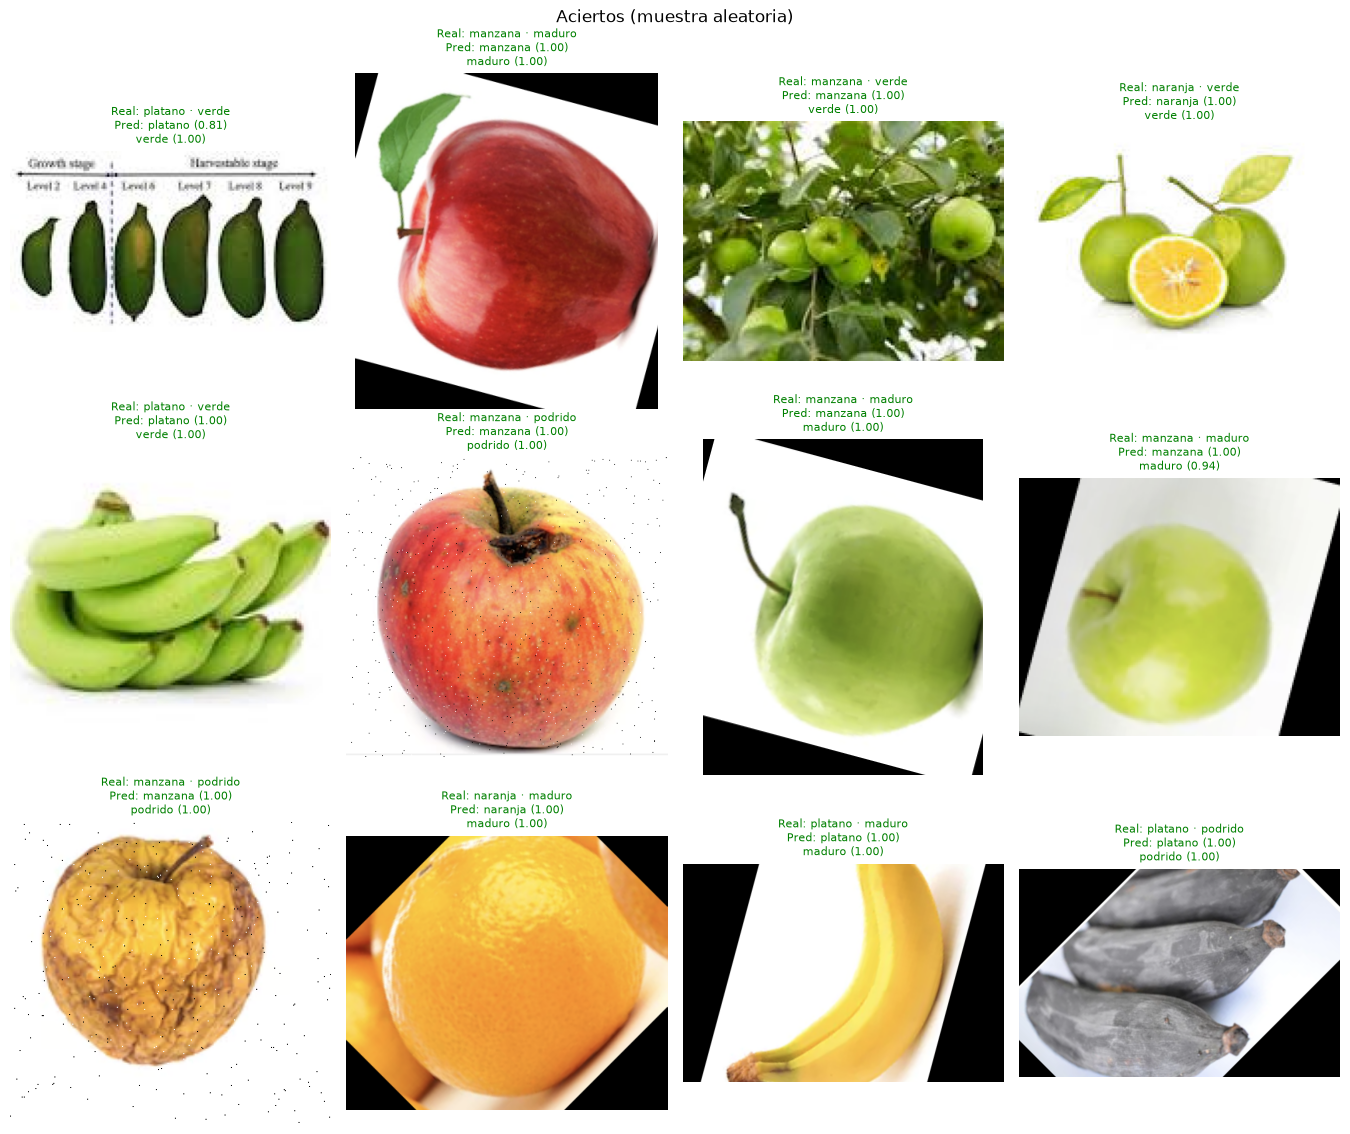

Errores totales: 29


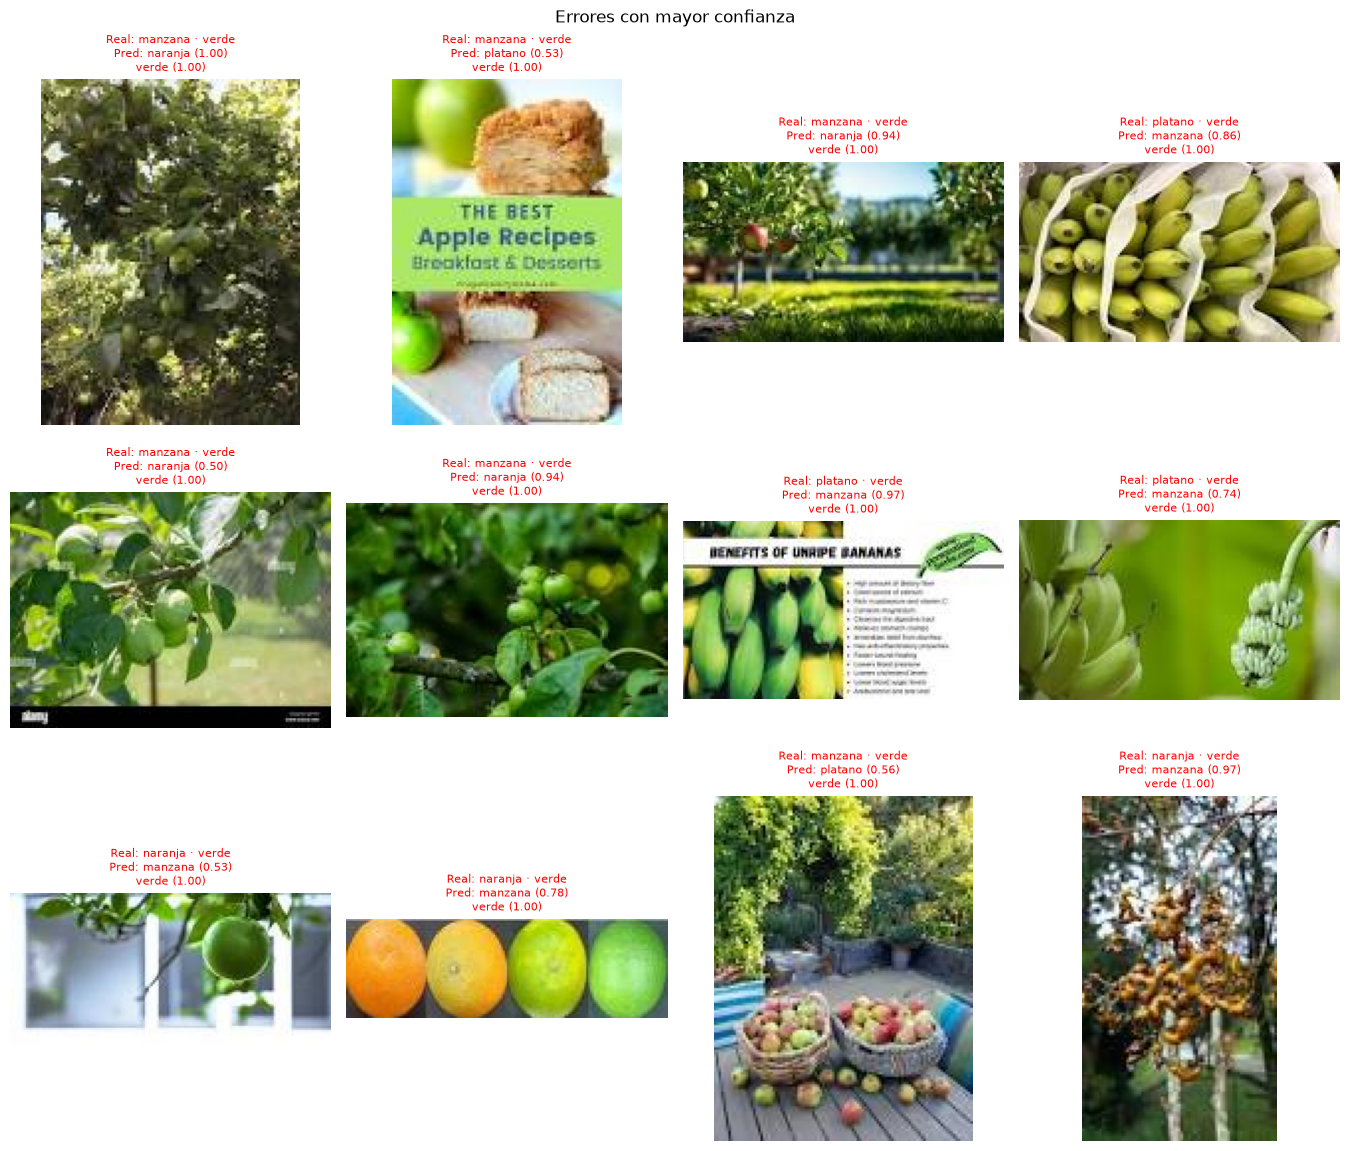

real             pred           
manzana-verde    naranja-verde      8
naranja-verde    manzana-verde      6
manzana-podrido  manzana-maduro     5
platano-verde    manzana-verde      3
manzana-maduro   manzana-verde      2
manzana-verde    platano-verde      2
                 manzana-maduro     1
naranja-podrido  manzana-podrido    1
naranja-verde    naranja-maduro     1
dtype: int64

In [16]:
def etiqueta(r, pred=False):
    if pred:
        return f"{PRODUCTOS[r.pred_prod]} ({r.conf_prod:.2f})\n{MADUREZ[r.pred_mad]} ({r.conf_mad:.2f})"
    return f"{r.producto} · {r.madurez}"

def mostrar(sub, titulo, archivo, n=12):
    sub = sub.head(n)
    if len(sub) == 0:
        print("Sin ejemplos para:", titulo); return
    cols = 4; filas = int(np.ceil(len(sub) / cols))
    fig, axes = plt.subplots(filas, cols, figsize=(cols * 3.4, filas * 3.9))
    for ax in np.array(axes).ravel(): ax.axis("off")
    for ax, (_, r) in zip(np.array(axes).ravel(), sub.iterrows()):
        ax.imshow(Image.open(r.ruta).convert("RGB"))
        ax.set_title(f"Real: {etiqueta(r)}\nPred: {etiqueta(r, True)}", fontsize=8,
                     color="green" if r.ok_ambas else "red")
    fig.suptitle(titulo); plt.tight_layout(); plt.savefig(FIG_DIR / archivo, dpi=150); plt.show()

mostrar(res[res.ok_ambas].sample(12, random_state=SEED), "Aciertos (muestra aleatoria)", "predicciones_aciertos.png")
errores = res[~res.ok_ambas].sort_values("conf_mad", ascending=False)
print("Errores totales:", len(errores))
mostrar(errores, "Errores con mayor confianza", "predicciones_errores.png")

# ¿Qué confusiones ocurren más?
errores.assign(real=errores.clase,
               pred=[f"{PRODUCTOS[a]}-{MADUREZ[b]}" for a, b in zip(errores.pred_prod, errores.pred_mad)]
              ).groupby(["real", "pred"]).size().sort_values(ascending=False).head(10)

## 13. Prueba fuera de dominio: fotografías propias
Fotos tomadas con celular (fondos e iluminación reales), guardadas en la carpeta `fotos_propias/`. Sirven para ver cómo se comporta el modelo fuera de las condiciones del dataset.

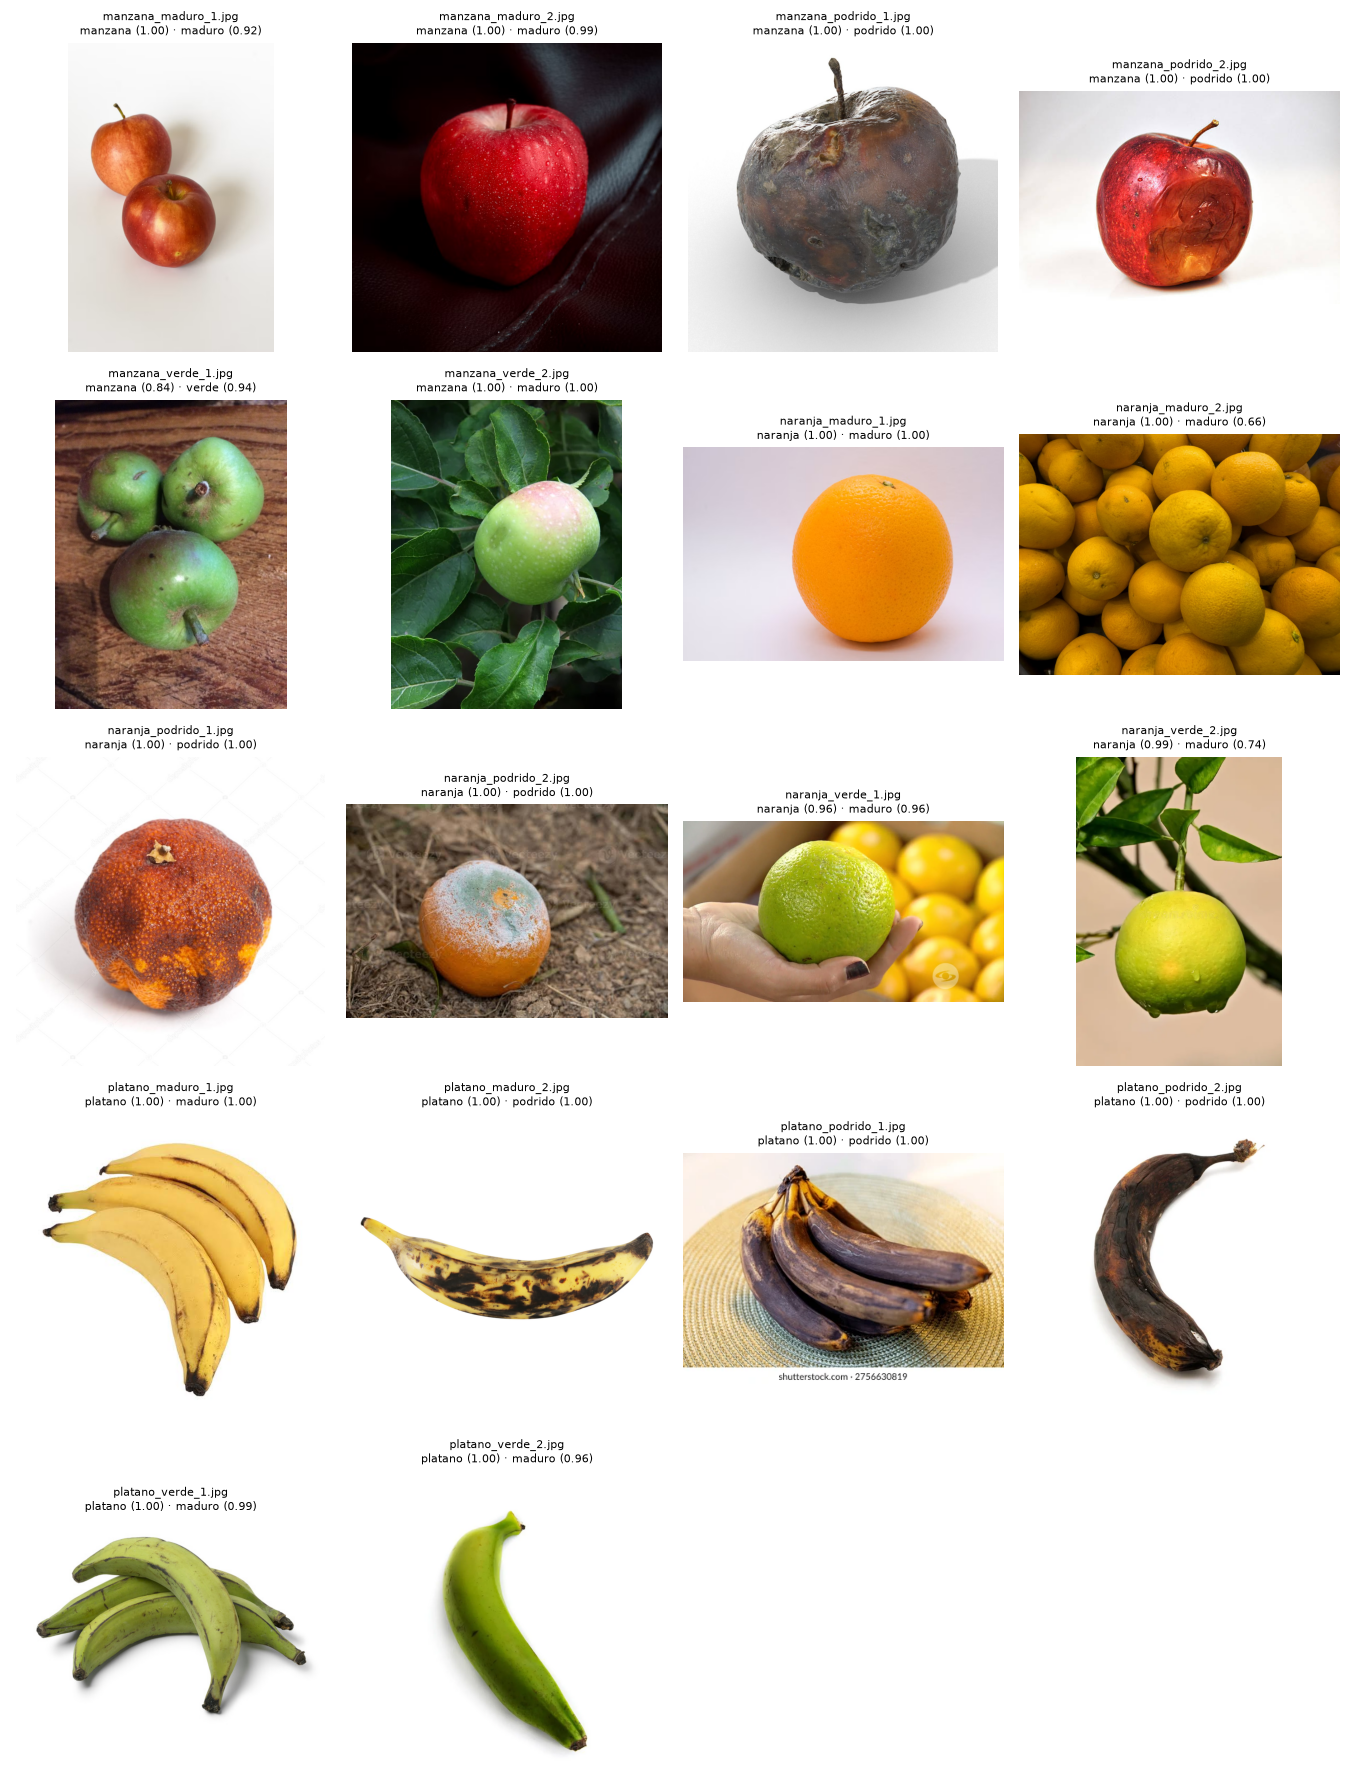

In [17]:
FOTOS = Path("fotos_propias")
rutas = sorted([p for p in FOTOS.glob("*") if p.suffix.lower() in EXT]) if FOTOS.exists() else []
if not rutas:
    print("No hay fotos en 'fotos_propias/'. Agrega imágenes y vuelve a ejecutar esta celda.")
else:
    cols = 4; filas = int(np.ceil(len(rutas) / cols))
    fig, axes = plt.subplots(filas, cols, figsize=(cols * 3.4, filas * 3.6))
    for ax in np.array(axes).ravel(): ax.axis("off")
    with torch.no_grad():
        for ax, ruta in zip(np.array(axes).ravel(), rutas):
            img = Image.open(ruta).convert("RGB")
            lp, lm = model(tf_eval(img).unsqueeze(0).to(device))
            pp, pm = lp.softmax(1)[0].cpu(), lm.softmax(1)[0].cpu()
            ax.imshow(img)
            ax.set_title(f"{ruta.name}\n{PRODUCTOS[pp.argmax()]} ({pp.max():.2f}) · "
                         f"{MADUREZ[pm.argmax()]} ({pm.max():.2f})", fontsize=8)
    plt.tight_layout(); plt.savefig(FIG_DIR / "fotos_propias.png", dpi=150); plt.show()

## 14. Guardar el modelo final

In [18]:
torch.save({"state_dict": model.state_dict(), "productos": PRODUCTOS, "madurez": MADUREZ,
            "cfg": CFG, "mejor_epoca": mejor["epoca"]}, "clasificador_madurez_mobilenetv2.pth")
print("Modelo guardado. Tamaño:", round(os.path.getsize("clasificador_madurez_mobilenetv2.pth") / 1e6, 2), "MB")

Modelo guardado. Tamaño: 9.18 MB
